
# Sentiment Analysis Notebook 



## What this notebook includes
- clean labels and section headings
- word cloud
- **top unigrams, bigrams, and trigrams**
- VADER sentiment
- BERT sentiment
- **VADER vs. BERT comparison**
- **average VADER score by rating**
- **BERT sentiment distribution by rating**
- **sentiment by business**
- **top complaint themes by business**
- a final section explaining **why BERT should be the main model for suggestions**


In [4]:

# ==============================
# 1. Setup and Imports
# ==============================

import warnings
warnings.filterwarnings('ignore')

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
from IPython.display import display, Markdown

import nltk
from nltk.sentiment import SentimentIntensityAnalyzer
from nltk.corpus import stopwords
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer
from tqdm.auto import tqdm

for pkg in ['stopwords', 'vader_lexicon']:
    nltk.download(pkg)

pd.set_option('display.max_colwidth', 250)
sns.set_theme(style='whitegrid')


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/ujjwalsharma/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/ujjwalsharma/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!



## 2. Load Dataset




In [5]:

# ==============================
# 2. Load Dataset
# ==============================

CSV_PATH = 'finaldataset (1).csv'

df_raw = pd.read_csv(CSV_PATH)
print('Shape:', df_raw.shape)
print('\nColumns:')
print(list(df_raw.columns))
display(df_raw.head())


Shape: (11215, 14)

Columns:
['Unnamed: 0', 'author_location', 'author_name', 'business_id', 'business_name', 'created_date', 'language', 'rating', 'reactions/helpful', 'reactions/love_this', 'reactions/oh_no', 'reactions/thanks', 'review_id', 'text']


,Unnamed: 0,author_location,author_name,business_id,business_name,created_date,language,rating,reactions/helpful,reactions/love_this,reactions/oh_no,reactions/thanks,review_id,text
0,0,"Sacramento, CA",Travis H.,k_ciTXeO_yLLHFvHkHGuPA,Bawk! by Urban Roots,2026-02-14 23:13:54+00:00,en,5,0,0,0,0,noyI7YsdQTMWHaepzm5p2g,"I will say first and foremost, this is \nMy place. Everything here is awesome.. Chicken... perfect.\nSalad.... yup. Perfect. \nOysters... OUI! Je suis Travis! \nBartenders... the best. \n\nThe funky murals and decor always put a smile..."
1,1,"San Francisco, CA",Rob M.,k_ciTXeO_yLLHFvHkHGuPA,Bawk! by Urban Roots,2026-02-03 01:00:21+00:00,en,1,0,0,0,0,K4zMpD5a1IOw9DuN2lhC1A,"Great cauliflower wings. Horrible service\nI wanted to order more things but they don't like to be bothered. Don't think the staff there especially the Hispanic lady, wants to be there at all lol \nPlease hire a new staff that wants to sell your ..."
2,2,"Sacramento, CA",Audra D.,k_ciTXeO_yLLHFvHkHGuPA,Bawk! by Urban Roots,2026-03-22 14:10:44+00:00,en,4,0,0,0,0,N8_lGvIi1aGBNNNYsld5VA,"Came for their happy hour and they had $5 dirty martinis which were made to perfection! We had boneless chicken wings, fries and a chicken sandwich which tasted so good and it was full of flavor. I love that the happy hour had a variety of optio..."
3,3,"Sacramento, CA",Colleen R.,k_ciTXeO_yLLHFvHkHGuPA,Bawk! by Urban Roots,2026-01-26 20:20:23+00:00,en,4,8,11,0,3,fJQ7NJSuH1eZiqCCaODT3Q,"Came to Bawk! by Urban Roots recently, and it was such a great spot. I met up with some girlfriends I hadn't seen in months, so it was the perfect place to catch up, hang out, and share a bunch of food. We ended up sitting there for hours just ta..."
4,4,"San Francisco, CA",Michele T.,k_ciTXeO_yLLHFvHkHGuPA,Bawk! by Urban Roots,2026-03-01 20:51:38+00:00,en,4,0,1,0,0,O86HkYJKxof3u_k6_PvUMg,The Chicken & Waffles caught my attention and it didn't disappoint. Crispy chicken wings. Loved the cornbread waffle and maple butter - not too sweet.



## 3. Prepare the Main Columns


- `text`
- `rating`
- `business_name`
- `created_date`


In [6]:

# ==============================
# 3. Prepare the Main Columns
# ==============================

df = df_raw.copy()

df['review_text'] = df['text'].astype(str)
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')
df['business_name_std'] = df['business_name'].astype(str)
df['created_date_std'] = pd.to_datetime(df['created_date'], errors='coerce')

df = df[df['review_text'].str.strip().ne('')].copy()
df = df.dropna(subset=['rating']).copy()

df['rating'] = df['rating'].astype(int)

print('Working shape:', df.shape)
display(df[['business_name_std', 'rating', 'created_date_std', 'review_text']].head())


Working shape: (11215, 17)


,business_name_std,rating,created_date_std,review_text
0,Bawk! by Urban Roots,5,2026-02-14 23:13:54+00:00,"I will say first and foremost, this is \nMy place. Everything here is awesome.. Chicken... perfect.\nSalad.... yup. Perfect. \nOysters... OUI! Je suis Travis! \nBartenders... the best. \n\nThe funky murals and decor always put a smile..."
1,Bawk! by Urban Roots,1,2026-02-03 01:00:21+00:00,"Great cauliflower wings. Horrible service\nI wanted to order more things but they don't like to be bothered. Don't think the staff there especially the Hispanic lady, wants to be there at all lol \nPlease hire a new staff that wants to sell your ..."
2,Bawk! by Urban Roots,4,2026-03-22 14:10:44+00:00,"Came for their happy hour and they had $5 dirty martinis which were made to perfection! We had boneless chicken wings, fries and a chicken sandwich which tasted so good and it was full of flavor. I love that the happy hour had a variety of optio..."
3,Bawk! by Urban Roots,4,2026-01-26 20:20:23+00:00,"Came to Bawk! by Urban Roots recently, and it was such a great spot. I met up with some girlfriends I hadn't seen in months, so it was the perfect place to catch up, hang out, and share a bunch of food. We ended up sitting there for hours just ta..."
4,Bawk! by Urban Roots,4,2026-03-01 20:51:38+00:00,The Chicken & Waffles caught my attention and it didn't disappoint. Crispy chicken wings. Loved the cornbread waffle and maple butter - not too sweet.



## 4. Quick Look at the Ratings


,count
rating,
1,801
2,603
3,947
4,2231
5,6633


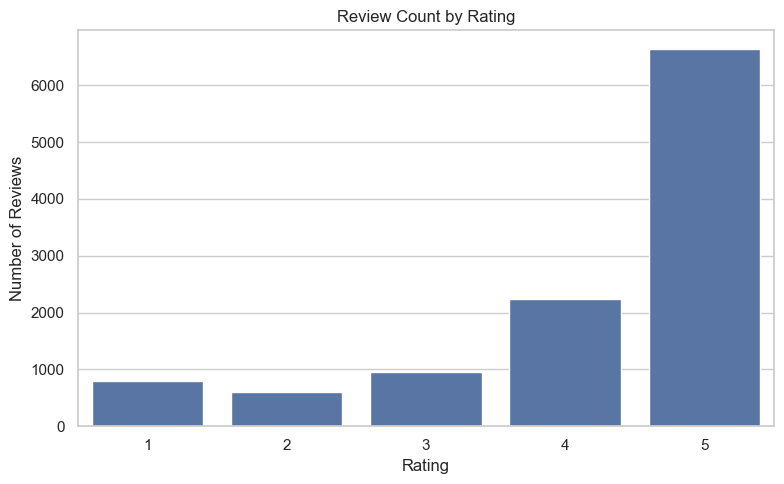

In [7]:

# ==============================
# 4. Quick Look at the Ratings
# ==============================

rating_counts = df['rating'].value_counts().sort_index().rename_axis('rating').to_frame('count')
display(rating_counts)

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='rating', order=sorted(df['rating'].unique()))
plt.title('Review Count by Rating')
plt.xlabel('Rating')
plt.ylabel('Number of Reviews')
plt.tight_layout()
plt.show()



## 5. Clean the Text for Word Patterns

This cleaned text will be used for the word cloud, unigrams, bigrams, trigrams, and complaint-theme analysis.


In [8]:

# ==============================
# 5. Clean the Text
# ==============================

STOPWORDS = set(stopwords.words('english'))
EXTRA_STOPWORDS = {
    'restaurant', 'place', 'food', 'one', 'really', 'get', 'got', 'also', 'would',
    'back', 'go', 'went', 'came', 'could', 'like', 'im', 'ive', 'us'
}
STOPWORDS = STOPWORDS.union(EXTRA_STOPWORDS)


def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = [word for word in text.split() if word not in STOPWORDS and len(word) > 2]
    return ' '.join(tokens)


df['clean_text'] = df['review_text'].apply(clean_text)
display(df[['review_text', 'clean_text']].head())


,review_text,clean_text
0,"I will say first and foremost, this is \nMy place. Everything here is awesome.. Chicken... perfect.\nSalad.... yup. Perfect. \nOysters... OUI! Je suis Travis! \nBartenders... the best. \n\nThe funky murals and decor always put a smile...",say first foremost everything awesome chicken perfect salad yup perfect oysters oui suis travis bartenders best funky murals decor always put smile face muhammad ali rad forever love chicken unapologetically perfect burger unabashedly needed come...
1,"Great cauliflower wings. Horrible service\nI wanted to order more things but they don't like to be bothered. Don't think the staff there especially the Hispanic lady, wants to be there at all lol \nPlease hire a new staff that wants to sell your ...",great cauliflower wings horrible service wanted order things bothered think staff especially hispanic lady wants lol please hire new staff wants sell public wants business thrive reevaluate cashiers hire someone wants serve happened fried chicken...
2,"Came for their happy hour and they had $5 dirty martinis which were made to perfection! We had boneless chicken wings, fries and a chicken sandwich which tasted so good and it was full of flavor. I love that the happy hour had a variety of optio...",happy hour dirty martinis made perfection boneless chicken wings fries chicken sandwich tasted good full flavor love happy hour variety options great drinks lucky meet owner spider monkey gave complimentary beignets soooo good fluffy warm melted ...
3,"Came to Bawk! by Urban Roots recently, and it was such a great spot. I met up with some girlfriends I hadn't seen in months, so it was the perfect place to catch up, hang out, and share a bunch of food. We ended up sitting there for hours just ta...",bawk urban roots recently great spot met girlfriends seen months perfect catch hang share bunch ended sitting hours talking laughing never felt rushed appreciated solid perfect sharing ordered mac cheese oysters fried cauliflower mac cheese cream...
4,The Chicken & Waffles caught my attention and it didn't disappoint. Crispy chicken wings. Loved the cornbread waffle and maple butter - not too sweet.,chicken waffles caught attention disappoint crispy chicken wings loved cornbread waffle maple butter sweet



## 6. Word Cloud


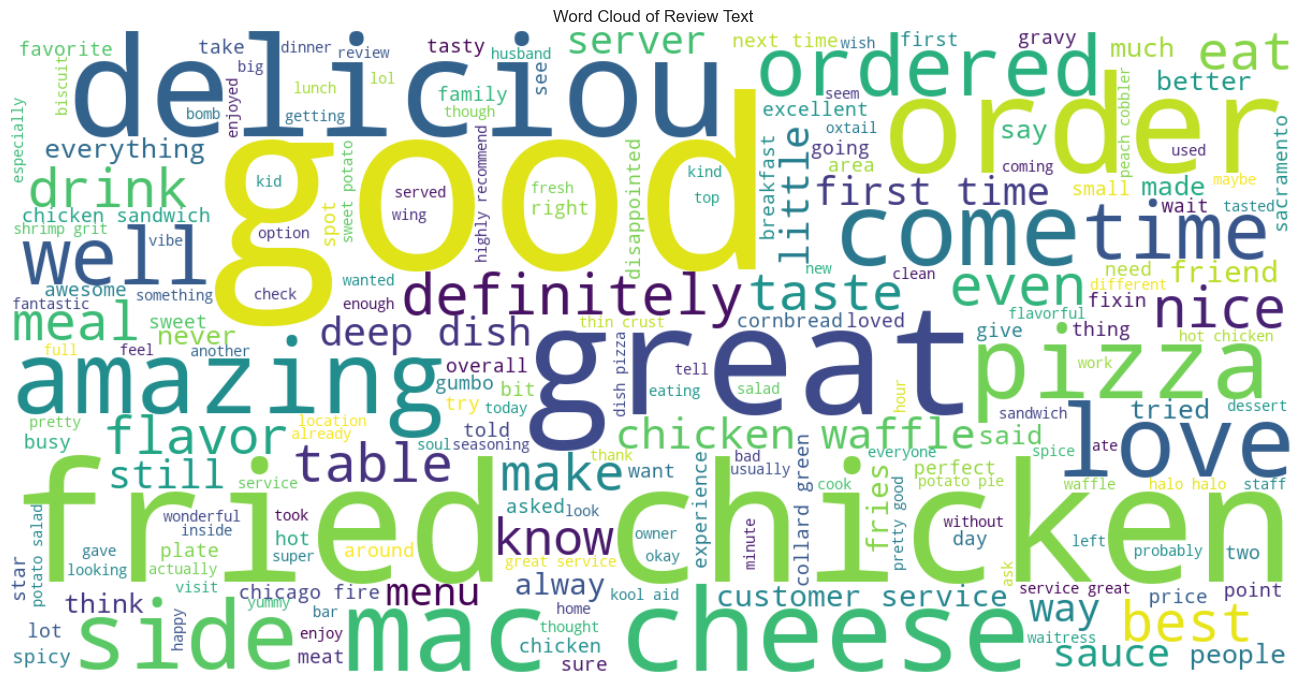

In [9]:

# ==============================
# 6. Word Cloud
# ==============================

all_text = ' '.join(df['clean_text'].dropna())
wordcloud = WordCloud(width=1200, height=600, background_color='white').generate(all_text)

plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Review Text')
plt.tight_layout()
plt.show()



## 7. Top Unigrams, Bigrams, and Trigrams

These are important because they show the common ideas in the reviews, not just the sentiment score.


In [10]:

# ==============================
# 7. N-gram Helper Function
# ==============================

def get_top_ngrams(text_series, ngram_range=(1, 1), top_n=15, min_df=3):
    text_series = text_series.dropna()
    text_series = text_series[text_series.str.strip().ne('')]

    vectorizer = CountVectorizer(ngram_range=ngram_range, min_df=min_df)
    X = vectorizer.fit_transform(text_series)
    counts = np.asarray(X.sum(axis=0)).ravel()
    terms = np.array(vectorizer.get_feature_names_out())

    top_idx = counts.argsort()[::-1][:top_n]
    return pd.DataFrame({'term': terms[top_idx], 'count': counts[top_idx]})


,term,count
0,chicken,9781
1,good,7560
2,great,4963
3,service,4599
4,fried,4244
5,time,3807
6,order,2965
7,ordered,2945
8,cheese,2735
9,delicious,2713


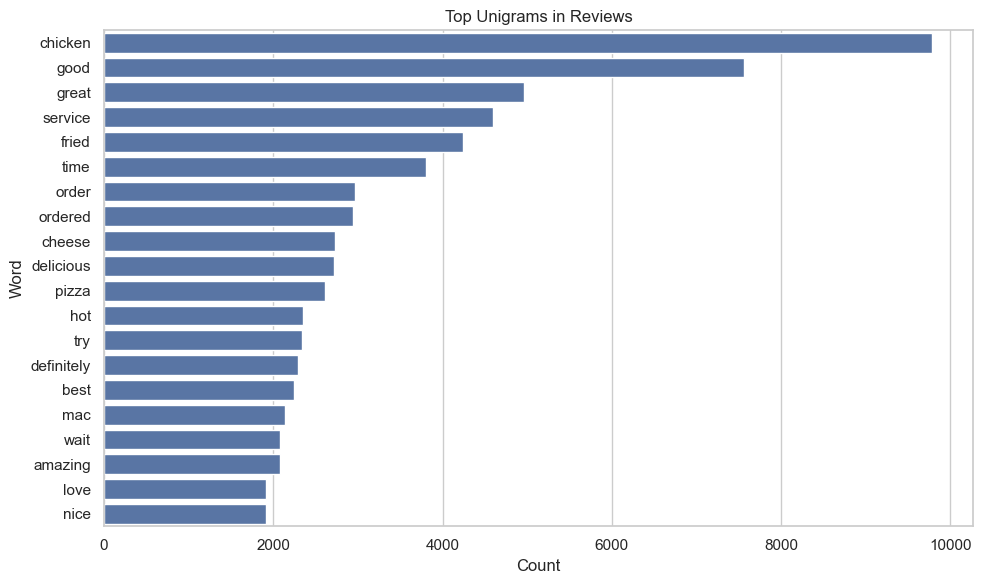

In [11]:

# ==============================
# 8. Top Unigrams
# ==============================

top_unigrams = get_top_ngrams(df['clean_text'], ngram_range=(1, 1), top_n=20, min_df=5)
display(top_unigrams)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_unigrams, y='term', x='count')
plt.title('Top Unigrams in Reviews')
plt.xlabel('Count')
plt.ylabel('Word')
plt.tight_layout()
plt.show()


,term,count
0,fried chicken,2580
1,mac cheese,1910
2,deep dish,897
3,first time,872
4,customer service,822
5,chicken waffles,795
6,chicken sandwich,736
7,chicago fire,614
8,collard greens,510
9,next time,488


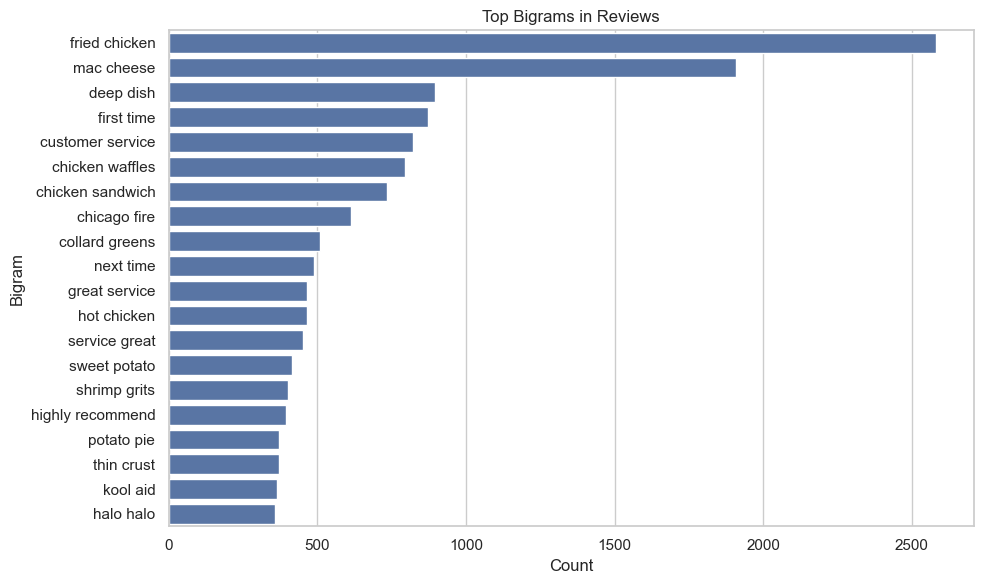

In [12]:

# ==============================
# 9. Top Bigrams
# ==============================

top_bigrams = get_top_ngrams(df['clean_text'], ngram_range=(2, 2), top_n=20, min_df=5)
display(top_bigrams)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_bigrams, y='term', x='count')
plt.title('Top Bigrams in Reviews')
plt.xlabel('Count')
plt.ylabel('Bigram')
plt.tight_layout()
plt.show()


,term,count
0,sweet potato pie,372
1,deep dish pizza,283
2,red beans rice,262
3,fried green tomatoes,205
4,fried deviled eggs,176
5,black eyed peas,165
6,chicken fried steak,151
7,great customer service,148
8,ordered fried chicken,137
9,greens mac cheese,133


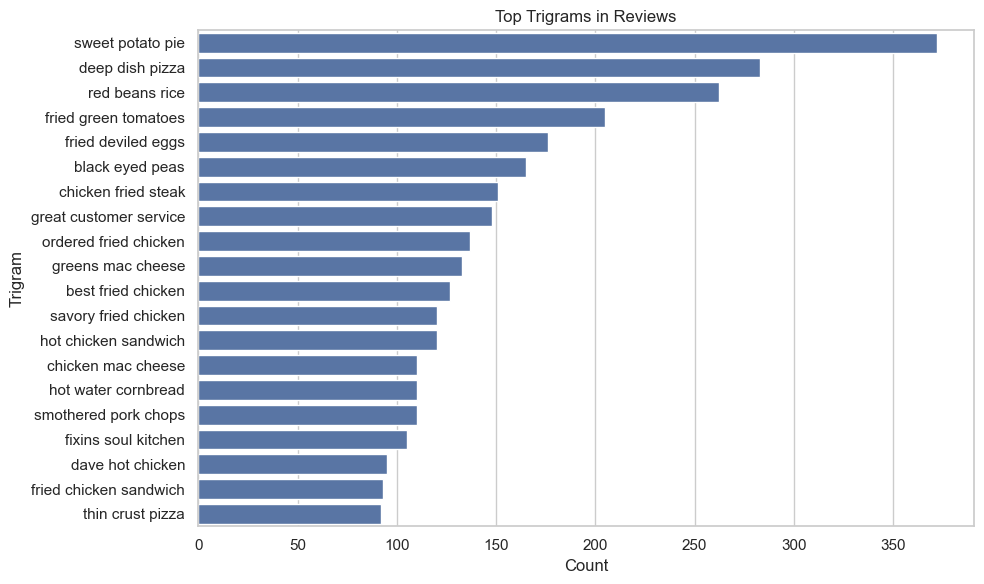

In [13]:

# ==============================
# 10. Top Trigrams
# ==============================

top_trigrams = get_top_ngrams(df['clean_text'], ngram_range=(3, 3), top_n=20, min_df=4)
display(top_trigrams)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_trigrams, y='term', x='count')
plt.title('Top Trigrams in Reviews')
plt.xlabel('Count')
plt.ylabel('Trigram')
plt.tight_layout()
plt.show()



## 8. VADER Sentiment Analysis

VADER is useful because it is simple and fast, but it is still rule-based.


,rating,review_text,compound,vader_label
0,5,"I will say first and foremost, this is \nMy place. Everything here is awesome.. Chicken... perfect.\nSalad.... yup. Perfect. \nOysters... OUI! Je suis Travis! \nBartenders... the best. \n\nThe funky murals and decor always put a smile...",0.9735,Positive
1,1,"Great cauliflower wings. Horrible service\nI wanted to order more things but they don't like to be bothered. Don't think the staff there especially the Hispanic lady, wants to be there at all lol \nPlease hire a new staff that wants to sell your ...",0.7457,Positive
2,4,"Came for their happy hour and they had $5 dirty martinis which were made to perfection! We had boneless chicken wings, fries and a chicken sandwich which tasted so good and it was full of flavor. I love that the happy hour had a variety of optio...",0.9870,Positive
3,4,"Came to Bawk! by Urban Roots recently, and it was such a great spot. I met up with some girlfriends I hadn't seen in months, so it was the perfect place to catch up, hang out, and share a bunch of food. We ended up sitting there for hours just ta...",0.9970,Positive
4,4,The Chicken & Waffles caught my attention and it didn't disappoint. Crispy chicken wings. Loved the cornbread waffle and maple butter - not too sweet.,0.5687,Positive


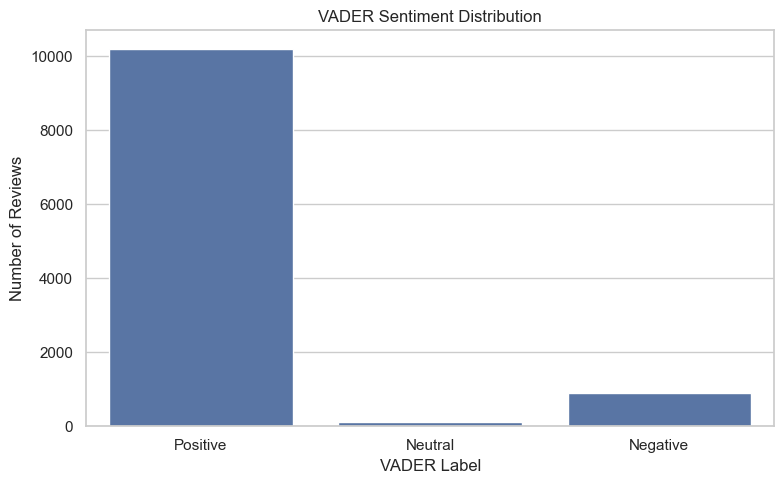

In [14]:

# ==============================
# 11. VADER Sentiment Analysis
# ==============================

sia = SentimentIntensityAnalyzer()


def vader_label(compound):
    if compound >= 0.05:
        return 'Positive'
    elif compound <= -0.05:
        return 'Negative'
    return 'Neutral'

vader_scores = df['review_text'].apply(sia.polarity_scores).apply(pd.Series)
df = pd.concat([df, vader_scores], axis=1)
df['vader_label'] = df['compound'].apply(vader_label)

display(df[['rating', 'review_text', 'compound', 'vader_label']].head())

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='vader_label', order=['Positive', 'Neutral', 'Negative'])
plt.title('VADER Sentiment Distribution')
plt.xlabel('VADER Label')
plt.ylabel('Number of Reviews')
plt.tight_layout()
plt.show()



## 9. BERT Sentiment Analysis

BERT is more context-aware than VADER, so it is the better model to use for final suggestions and business recommendations.


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Scoring with BERT:   0%|          | 0/351 [00:00<?, ?it/s]

,rating,review_text,bert_label,bert_score
0,5,"I will say first and foremost, this is \nMy place. Everything here is awesome.. Chicken... perfect.\nSalad.... yup. Perfect. \nOysters... OUI! Je suis Travis! \nBartenders... the best. \n\nThe funky murals and decor always put a smile...",Positive,0.999860
1,1,"Great cauliflower wings. Horrible service\nI wanted to order more things but they don't like to be bothered. Don't think the staff there especially the Hispanic lady, wants to be there at all lol \nPlease hire a new staff that wants to sell your ...",Negative,0.933790
2,4,"Came for their happy hour and they had $5 dirty martinis which were made to perfection! We had boneless chicken wings, fries and a chicken sandwich which tasted so good and it was full of flavor. I love that the happy hour had a variety of optio...",Positive,0.999864
3,4,"Came to Bawk! by Urban Roots recently, and it was such a great spot. I met up with some girlfriends I hadn't seen in months, so it was the perfect place to catch up, hang out, and share a bunch of food. We ended up sitting there for hours just ta...",Positive,0.999808
4,4,The Chicken & Waffles caught my attention and it didn't disappoint. Crispy chicken wings. Loved the cornbread waffle and maple butter - not too sweet.,Positive,0.999612


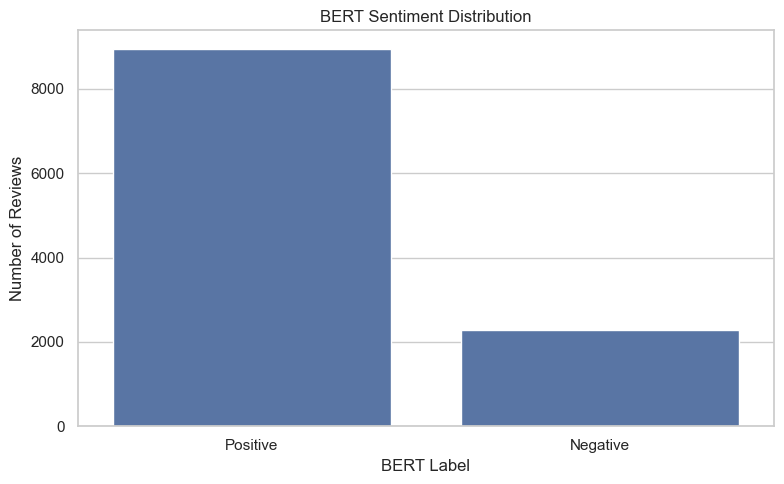

In [15]:

# ==============================
# 12. BERT Sentiment Analysis
# ==============================

from transformers import pipeline

MODEL_NAME = 'distilbert-base-uncased-finetuned-sst-2-english'
BATCH_SIZE = 32

bert_pipe = pipeline('sentiment-analysis', model=MODEL_NAME, truncation=True)

reviews = df['review_text'].fillna('').tolist()
outputs = []

for i in tqdm(range(0, len(reviews), BATCH_SIZE), desc='Scoring with BERT'):
    batch = reviews[i:i+BATCH_SIZE]
    outputs.extend(bert_pipe(batch))

df['bert_label_raw'] = [x['label'] for x in outputs]
df['bert_score'] = [x['score'] for x in outputs]
df['bert_label'] = df['bert_label_raw'].str.title()

display(df[['rating', 'review_text', 'bert_label', 'bert_score']].head())

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='bert_label', order=['Positive', 'Negative'])
plt.title('BERT Sentiment Distribution')
plt.xlabel('BERT Label')
plt.ylabel('Number of Reviews')
plt.tight_layout()
plt.show()



## 10. VADER vs. BERT Comparison

This section matters because the two models do not always behave the same way.

### Main idea
- **VADER** may overrate mixed reviews as positive because it reacts strongly to positive words.
- **BERT** usually handles context better, so it is more useful for final suggestions.


bert_label,Negative,Positive
vader_label,,
Negative,798,106
Neutral,83,39
Positive,1391,8798


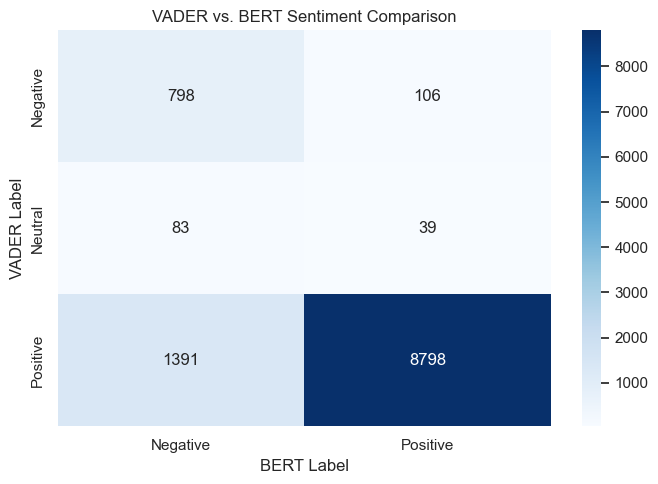

In [16]:

# ==============================
# 13. Overall Model Comparison
# ==============================

comparison_ct = pd.crosstab(df['vader_label'], df['bert_label'])
display(comparison_ct)

plt.figure(figsize=(7, 5))
sns.heatmap(comparison_ct, annot=True, fmt='g', cmap='Blues')
plt.title('VADER vs. BERT Sentiment Comparison')
plt.xlabel('BERT Label')
plt.ylabel('VADER Label')
plt.tight_layout()
plt.show()


In [17]:

# ==============================
# 14. Reviews Where VADER and BERT Disagree
# ==============================

disagreement_df = df[
    ((df['vader_label'] == 'Positive') & (df['bert_label'] == 'Negative')) |
    ((df['vader_label'] == 'Negative') & (df['bert_label'] == 'Positive')) |
    ((df['vader_label'] == 'Neutral') & (df['bert_label'].isin(['Positive', 'Negative'])))
].copy()

print('Number of disagreement / mixed-interest reviews:', len(disagreement_df))

display(
    disagreement_df[
        ['rating', 'business_name_std', 'compound', 'vader_label', 'bert_label', 'bert_score', 'review_text']
    ].head(15)
)


Number of disagreement / mixed-interest reviews: 1619


,rating,business_name_std,compound,vader_label,bert_label,bert_score,review_text
1,1,Bawk! by Urban Roots,0.7457,Positive,Negative,0.933790,"Great cauliflower wings. Horrible service\nI wanted to order more things but they don't like to be bothered. Don't think the staff there especially the Hispanic lady, wants to be there at all lol \nPlease hire a new staff that wants to sell your ..."
6,2,Bawk! by Urban Roots,0.9459,Positive,Negative,0.999542,"I'm so disappointed! I used to be a regular at Bawk 3.5 years ago. Their red beans & rice were my favorite. They were seasoned perfectly, but they changed the menu and took it off the menu. I went back for the first time in years and was excited..."
28,2,Bawk! by Urban Roots,-0.0387,Neutral,Positive,0.861859,"I ordered my food and was quoted a 10-15 minute wait, but it ended up taking about 30 minutes. What made the experience frustrating was that I personally saw multiple customers who ordered after me receive their food before I did.\n\nI don't mind..."
32,3,Bawk! by Urban Roots,0.9153,Positive,Negative,0.968961,I ordered 6 buckets of chicken for an engagement party for a 4pm pickup on Saturday. Upon arriving our family member who picked them up. Alerted the front counter. He arrived 15mins. Prior and ended up waiting 45. He was told that they wanted to...
39,4,Chicago Fire,0.9802,Positive,Negative,0.984510,"On a rainy Saturday night, there was no wait to dine here. It was half full, and it felt very cozy inside. We were greeted by the hostess, and our server was nice. \n\nI was here to try the deep dish pizza, and they had a small selection of speci..."
43,5,Dave's Hot Chicken,0.5964,Positive,Negative,0.991916,I bought into the hype I have been seeing on the chilihead forums and gave this chain a shot. Can't speak to the dining area of the place itself because I have only ordered delivery through them. \n\n I will say of the half dozen times I have o...
44,1,Dave's Hot Chicken,0.3637,Positive,Negative,0.999486,"After being bombarded incessantly on YouTube we decided to check Dave's Hot Chicken out.\n\nThe hype was not worth the over seasoned, over cooked chicken we were served.\n\nWe will not be going back with so many better fried chicken options out t..."
46,1,Dave's Hot Chicken,0.2263,Positive,Negative,0.997515,I placed an order of 2 number 1s among other items and when I got home and opened them up I find that one plate had 3 tenders and the other only had 1 tender in it. Plus for 4 items plus 2 drinks it was over $50.
47,2,Dave's Hot Chicken,0.7921,Positive,Negative,0.999620,We went to the drive through ordered food . the food and fry's was not enough warm it was cold .\neven I ask the person who took our order to please make sure fresh .\nthey did not add any napkins in our gas .\nspending like $90 for cold food !
96,4,Bawk! by Urban Roots,-0.5095,Negative,Positive,0.551689,Okay maybe I'm the outlier here but this place is just OKAy!\n\nOrdered a Bawk chicken sandwich with honey mustard and a cider and I got to say I wasn't impressed. Honestly I was a bit disappointed in the lack of flavor on the chicken. The servi...



## 11. Sentiment by Rating

This helps answer:
- Do low ratings align with negative sentiment?
- Are 3-star reviews more mixed?
- Are there cases where the rating and text do not match?


,rating,review_count,avg_vader_compound,positive_share,negative_share
0,1,801,-0.112178,0.393258,0.555556
1,2,603,0.279024,0.638474,0.333333
2,3,947,0.622527,0.857445,0.122492
3,4,2231,0.856183,0.976244,0.019274
4,5,6633,0.870971,0.979798,0.014925


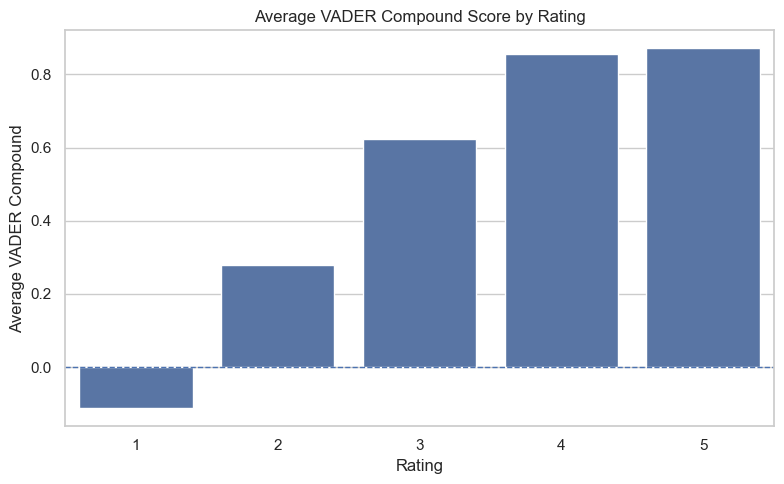

In [18]:

# ==============================
# 15. Average VADER Score by Rating
# ==============================

rating_vader = (
    df.groupby('rating')
      .agg(
          review_count=('review_text', 'size'),
          avg_vader_compound=('compound', 'mean'),
          positive_share=('vader_label', lambda s: (s == 'Positive').mean()),
          negative_share=('vader_label', lambda s: (s == 'Negative').mean())
      )
      .reset_index()
      .sort_values('rating')
)

display(rating_vader)

plt.figure(figsize=(8, 5))
sns.barplot(data=rating_vader, x='rating', y='avg_vader_compound')
plt.axhline(0, linestyle='--', linewidth=1)
plt.title('Average VADER Compound Score by Rating')
plt.xlabel('Rating')
plt.ylabel('Average VADER Compound')
plt.tight_layout()
plt.show()


bert_label,Negative,Positive
rating,,
1,96.8,3.2
2,85.6,14.4
3,55.6,44.4
4,11.3,88.7
5,3.1,96.9


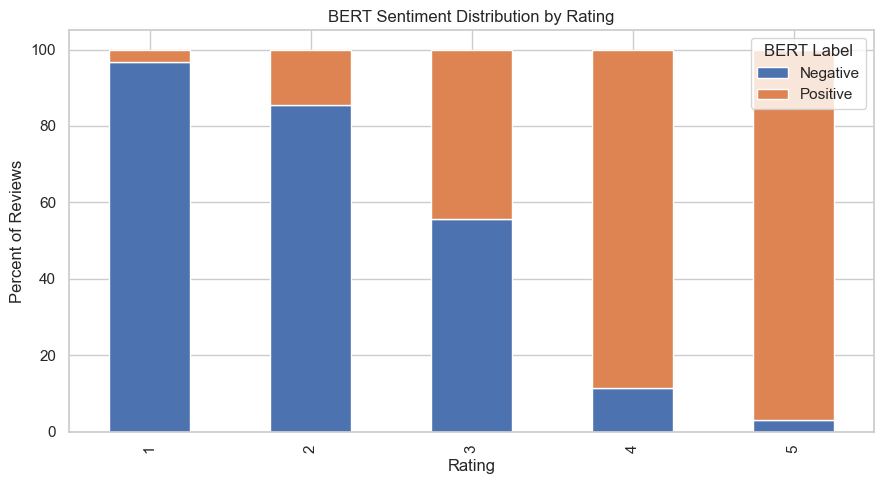

In [19]:

# ==============================
# 16. BERT Sentiment Distribution by Rating
# ==============================

rating_bert_table = pd.crosstab(df['rating'], df['bert_label'], normalize='index').mul(100).round(1)
display(rating_bert_table)

rating_bert_table.plot(kind='bar', stacked=True, figsize=(9, 5))
plt.title('BERT Sentiment Distribution by Rating')
plt.xlabel('Rating')
plt.ylabel('Percent of Reviews')
plt.legend(title='BERT Label')
plt.tight_layout()
plt.show()


In [20]:

# ==============================
# 17. Rating and BERT Alignment Check
# ==============================

def expected_from_rating(r):
    if r <= 2:
        return 'Negative'
    elif r == 3:
        return 'Mixed_or_Neutral'
    else:
        return 'Positive'


df['expected_sentiment_from_rating'] = df['rating'].apply(expected_from_rating)

df['bert_rating_alignment'] = np.where(
    ((df['expected_sentiment_from_rating'] == 'Positive') & (df['bert_label'] == 'Positive')) |
    ((df['expected_sentiment_from_rating'] == 'Negative') & (df['bert_label'] == 'Negative')),
    'Aligned',
    'Needs Review'
)

alignment_summary = pd.crosstab(df['rating'], df['bert_rating_alignment'])
display(alignment_summary)

interesting_rating_cases = df[df['bert_rating_alignment'] == 'Needs Review'][
    ['rating', 'business_name_std', 'bert_label', 'bert_score', 'review_text']
].head(15)

display(interesting_rating_cases)


bert_rating_alignment,Aligned,Needs Review
rating,,
1,775,26
2,516,87
3,0,947
4,1980,251
5,6430,203


,rating,business_name_std,bert_label,bert_score,review_text
7,3,Bawk! by Urban Roots,Positive,0.997664,Came here for a friends birthday dinner. Great thing is that you went up to the counter to order and pay for your food. It's nice because splitting a bill can be a chore. \n\nI had the lemon pepper chicken wings and waffle fries. The wings were ...
28,2,Bawk! by Urban Roots,Positive,0.861859,"I ordered my food and was quoted a 10-15 minute wait, but it ended up taking about 30 minutes. What made the experience frustrating was that I personally saw multiple customers who ordered after me receive their food before I did.\n\nI don't mind..."
32,3,Bawk! by Urban Roots,Negative,0.968961,I ordered 6 buckets of chicken for an engagement party for a 4pm pickup on Saturday. Upon arriving our family member who picked them up. Alerted the front counter. He arrived 15mins. Prior and ended up waiting 45. He was told that they wanted to...
39,4,Chicago Fire,Negative,0.984510,"On a rainy Saturday night, there was no wait to dine here. It was half full, and it felt very cozy inside. We were greeted by the hostess, and our server was nice. \n\nI was here to try the deep dish pizza, and they had a small selection of speci..."
43,5,Dave's Hot Chicken,Negative,0.991916,I bought into the hype I have been seeing on the chilihead forums and gave this chain a shot. Can't speak to the dining area of the place itself because I have only ordered delivery through them. \n\n I will say of the half dozen times I have o...
91,3,Bawk! by Urban Roots,Negative,0.998359,"If you're looking at the menu and struggling to decide what heat level you want on their scale of 1-5, fret not - it's all a 1."
105,4,Dave's Hot Chicken,Negative,0.968276,The chicken and fries were good but the bread was really bad. The service was good and I like that they have a baby changing table available. Not all establishment has one.
108,5,Dave's Hot Chicken,Negative,0.987014,"We had such a great experience at Dave's Hot Chicken today. Ethan was not only friendly and attentive with our order, but we also saw him go out of his way to bring food to a table for a woman with a baby so she didn't have to get up. You just do..."
116,3,Chicago Fire,Negative,0.980333,Pizza is very good but 17 dollars for 7 wings is ridiculous you would think you would make someone feel a bit better with the vegetables but nope 3 pieces of water logged celery come on guys 90 percent margin on chicken wings and celery \n\nAlso ...
125,5,Savory Fried Chicken,Negative,0.953978,"It's been a couple of years since I've had SFC and their food is still delicious. I used to do phone orders but now their online ordering system is better. It was easier to place an order and customize rice options: steamed, garlic or java. They ..."



## 12. Sentiment by Business

 this section makes the notebook more useful for recommendations.


In [21]:

# ==============================
# 18. Business Summary Table
# ==============================

MIN_REVIEWS_PER_BUSINESS = 5

business_summary = (
    df.groupby('business_name_std')
      .agg(
          review_count=('review_text', 'size'),
          avg_rating=('rating', 'mean'),
          avg_vader_compound=('compound', 'mean'),
          vader_negative_rate=('vader_label', lambda s: (s == 'Negative').mean()),
          bert_negative_rate=('bert_label', lambda s: (s == 'Negative').mean()),
          bert_positive_rate=('bert_label', lambda s: (s == 'Positive').mean())
      )
      .reset_index()
)

business_summary = business_summary[business_summary['review_count'] >= MIN_REVIEWS_PER_BUSINESS].copy()

print('Businesses included:', len(business_summary))
display(business_summary.head(10))


Businesses included: 10


,business_name_std,review_count,avg_rating,avg_vader_compound,vader_negative_rate,bert_negative_rate,bert_positive_rate
0,Angry Chickz,426,4.004695,0.637861,0.124413,0.258216,0.741784
1,Bawk! by Urban Roots,450,4.008889,0.747103,0.080000,0.191111,0.808889
2,Bear West BBQ & Soul Food,582,4.577320,0.813456,0.039519,0.115120,0.884880
3,Chicago Fire,1502,3.783622,0.713284,0.103196,0.288948,0.711052
4,Dave's Hot Chicken,657,4.327245,0.722175,0.086758,0.178082,0.821918
5,Fixins Soul Kitchen,3499,4.333524,0.774344,0.066019,0.167476,0.832524
6,Sarom's Southern Kitchen,1527,4.272430,0.785276,0.061559,0.167649,0.832351
7,Savory Fried Chicken,1234,3.915721,0.690785,0.106159,0.273906,0.726094
8,Tori's Place,636,4.281447,0.740407,0.088050,0.194969,0.805031
9,World Famous Hotboys,702,4.266382,0.706802,0.096866,0.219373,0.780627


Top businesses by BERT positive rate


,business_name_std,review_count,avg_rating,avg_vader_compound,vader_negative_rate,bert_negative_rate,bert_positive_rate
2,Bear West BBQ & Soul Food,582,4.577320,0.813456,0.039519,0.115120,0.884880
5,Fixins Soul Kitchen,3499,4.333524,0.774344,0.066019,0.167476,0.832524
6,Sarom's Southern Kitchen,1527,4.272430,0.785276,0.061559,0.167649,0.832351
4,Dave's Hot Chicken,657,4.327245,0.722175,0.086758,0.178082,0.821918
1,Bawk! by Urban Roots,450,4.008889,0.747103,0.080000,0.191111,0.808889
8,Tori's Place,636,4.281447,0.740407,0.088050,0.194969,0.805031
9,World Famous Hotboys,702,4.266382,0.706802,0.096866,0.219373,0.780627
0,Angry Chickz,426,4.004695,0.637861,0.124413,0.258216,0.741784
7,Savory Fried Chicken,1234,3.915721,0.690785,0.106159,0.273906,0.726094
3,Chicago Fire,1502,3.783622,0.713284,0.103196,0.288948,0.711052


Top businesses by BERT negative rate


,business_name_std,review_count,avg_rating,avg_vader_compound,vader_negative_rate,bert_negative_rate,bert_positive_rate
3,Chicago Fire,1502,3.783622,0.713284,0.103196,0.288948,0.711052
7,Savory Fried Chicken,1234,3.915721,0.690785,0.106159,0.273906,0.726094
0,Angry Chickz,426,4.004695,0.637861,0.124413,0.258216,0.741784
9,World Famous Hotboys,702,4.266382,0.706802,0.096866,0.219373,0.780627
8,Tori's Place,636,4.281447,0.740407,0.088050,0.194969,0.805031
1,Bawk! by Urban Roots,450,4.008889,0.747103,0.080000,0.191111,0.808889
4,Dave's Hot Chicken,657,4.327245,0.722175,0.086758,0.178082,0.821918
6,Sarom's Southern Kitchen,1527,4.272430,0.785276,0.061559,0.167649,0.832351
5,Fixins Soul Kitchen,3499,4.333524,0.774344,0.066019,0.167476,0.832524
2,Bear West BBQ & Soul Food,582,4.577320,0.813456,0.039519,0.115120,0.884880


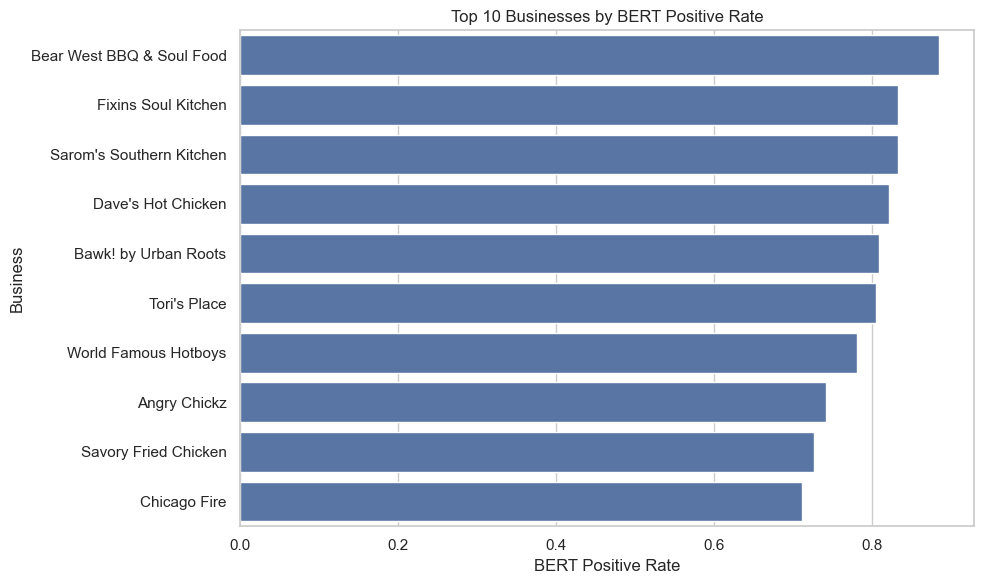

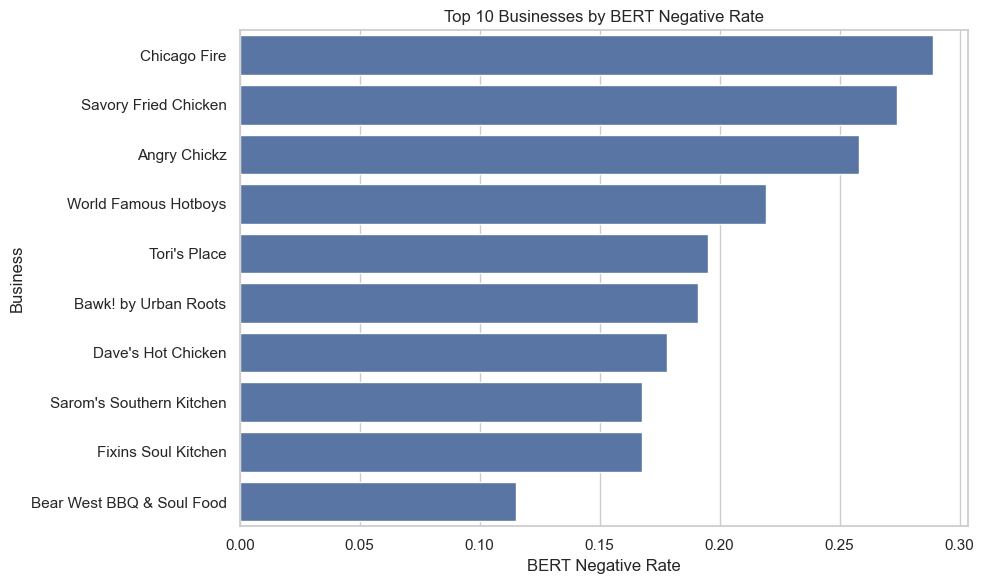

In [22]:

# ==============================
# 19. Top Positive and Negative Businesses
# ==============================

print('Top businesses by BERT positive rate')
display(
    business_summary.sort_values(['bert_positive_rate', 'review_count'], ascending=[False, False]).head(10)
)

print('Top businesses by BERT negative rate')
display(
    business_summary.sort_values(['bert_negative_rate', 'review_count'], ascending=[False, False]).head(10)
)

plt.figure(figsize=(10, 6))
top_positive_businesses = business_summary.sort_values('bert_positive_rate', ascending=False).head(10)
sns.barplot(data=top_positive_businesses, y='business_name_std', x='bert_positive_rate')
plt.title('Top 10 Businesses by BERT Positive Rate')
plt.xlabel('BERT Positive Rate')
plt.ylabel('Business')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
top_negative_businesses = business_summary.sort_values('bert_negative_rate', ascending=False).head(10)
sns.barplot(data=top_negative_businesses, y='business_name_std', x='bert_negative_rate')
plt.title('Top 10 Businesses by BERT Negative Rate')
plt.xlabel('BERT Negative Rate')
plt.ylabel('Business')
plt.tight_layout()
plt.show()



## 13. Top Complaint Themes by Business

To make suggestions, it makes more sense to use **BERT-negative reviews** and then inspect the bigrams and trigrams inside those reviews.


In [23]:

# ==============================
# 20. Complaint Themes by Business
# ==============================

def top_terms_for_subset(text_series, ngram_range=(2, 2), top_n=10, min_df=2):
    text_series = text_series.dropna()
    text_series = text_series[text_series.str.strip().ne('')]
    if len(text_series) < max(min_df, 2):
        return pd.DataFrame(columns=['term', 'count'])

    vectorizer = CountVectorizer(ngram_range=ngram_range, min_df=min_df)
    X = vectorizer.fit_transform(text_series)
    counts = np.asarray(X.sum(axis=0)).ravel()
    terms = np.array(vectorizer.get_feature_names_out())
    idx = counts.argsort()[::-1][:top_n]
    return pd.DataFrame({'term': terms[idx], 'count': counts[idx]})

most_negative_businesses = (
    business_summary.sort_values(['bert_negative_rate', 'review_count'], ascending=[False, False])
    .head(5)['business_name_std']
    .tolist()
)

for business in most_negative_businesses:
    print('\n' + '=' * 80)
    print('Business:', business)

    subset = df[(df['business_name_std'] == business) & (df['bert_label'] == 'Negative')]

    print('Top complaint bigrams')
    display(top_terms_for_subset(subset['clean_text'], ngram_range=(2, 2), top_n=10, min_df=2))

    print('Top complaint trigrams')
    display(top_terms_for_subset(subset['clean_text'], ngram_range=(3, 3), top_n=10, min_df=2))



Business: Chicago Fire
Top complaint bigrams


,term,count
0,deep dish,241
1,chicago fire,188
2,thin crust,97
3,dish pizza,72
4,chicago style,46
5,style pizza,35
6,greek fries,35
7,first time,33
8,crust pizza,30
9,stuffed pizza,28


Top complaint trigrams


,term,count
0,deep dish pizza,71
1,chicago style pizza,31
2,thin crust pizza,23
3,ordered deep dish,20
4,chicago fire pizza,16
5,chicago fire combo,11
6,deep dish pizzas,10
7,ordered thin crust,10
8,good deep dish,8
9,chicago deep dish,8



Business: Savory Fried Chicken
Top complaint bigrams


...

,term,count
0,nashville hot chicken,7
1,hot chicken sandwich,6
2,world famous hotboys,4
3,sandwich mac cheese,3
4,fries mac cheese,3
5,medium spicy chicken,3
6,hot chicken sandwiches,3
7,spicy next time,3
8,best fried chicken,3
9,chicken sandwich ever,2



Business: Tori's Place
Top complaint bigrams


,term,count
0,fried chicken,45
1,mac cheese,42
2,corn bread,27
3,hot water,21
4,water cornbread,15
5,customer service,14
6,peach cobbler,11
7,pork chops,10
8,banana pudding,9
9,first time,8


Top complaint trigrams


,term,count
0,hot water cornbread,15
1,fried chicken combo,6
2,black eyed peas,6
3,ordered fried chicken,6
4,hot water corn,4
5,good fried chicken,4
6,ordered snapper prawns,4
7,water corn bread,4
8,smothered pork chops,4
9,give another shot,3


In [24]:
# ==============================
# 20B. Positive Themes by Business
# ==============================

def top_terms_for_subset(text_series, ngram_range=(2, 2), top_n=10, min_df=2):
    text_series = text_series.dropna()
    text_series = text_series[text_series.str.strip().ne('')]
    if len(text_series) < max(min_df, 2):
        return pd.DataFrame(columns=['term', 'count'])

    vectorizer = CountVectorizer(ngram_range=ngram_range, min_df=min_df)
    X = vectorizer.fit_transform(text_series)
    counts = np.asarray(X.sum(axis=0)).ravel()
    terms = np.array(vectorizer.get_feature_names_out())
    idx = counts.argsort()[::-1][:top_n]
    return pd.DataFrame({'term': terms[idx], 'count': counts[idx]})


# Create positive-rate summary directly from df
positive_business_summary = (
    df.groupby('business_name_std')
      .agg(
          review_count=('bert_label', 'size'),
          positive_count=('bert_label', lambda x: (x == 'Positive').sum())
      )
      .reset_index()
)

positive_business_summary['bert_positive_rate'] = (
    positive_business_summary['positive_count'] / positive_business_summary['review_count']
)

most_positive_businesses = (
    positive_business_summary
    .sort_values(['bert_positive_rate', 'review_count'], ascending=[False, False])
    .head(5)['business_name_std']
    .tolist()
)

for business in most_positive_businesses:
    print('\n' + '=' * 80)
    print('Business:', business)

    subset = df[(df['business_name_std'] == business) & (df['bert_label'] == 'Positive')]

    print('Top praise bigrams')
    display(top_terms_for_subset(subset['clean_text'], ngram_range=(2, 2), top_n=10, min_df=2))

    print('Top praise trigrams')
    display(top_terms_for_subset(subset['clean_text'], ngram_range=(3, 3), top_n=10, min_df=2))


Business: Bear West BBQ & Soul Food
Top praise bigrams


,term,count
0,mac cheese,174
1,tri tip,144
2,baked beans,92
3,potato salad,84
4,bear west,70
5,green beans,65
6,bbq sauce,65
7,banana pudding,59
8,peach cobbler,55
9,pulled pork,53


Top praise trigrams


,term,count
0,bear west bbq,41
1,ribs tri tip,27
2,tri tip ribs,18
3,sides mac cheese,15
4,mac cheese baked,15
5,cheese baked beans,14
6,greens mac cheese,13
7,beans mac cheese,13
8,great customer service,12
9,west bbq soul,11



Business: Fixins Soul Kitchen
Top praise bigrams


...

,term,count
0,dave hot chicken,69
1,great customer service,40
2,amazing customer service,13
3,good customer service,8
4,excellent customer service,7
5,customer service amazing,7
6,best customer service,7
7,first time dave,7
8,customer service good,6
9,next time try,6



Business: Bawk! by Urban Roots
Top praise bigrams


,term,count
0,chicken sandwich,122
1,fried chicken,121
2,mac cheese,65
3,chicken waffles,42
4,bawk bites,38
5,urban roots,28
6,happy hour,28
7,hot chicken,25
8,first time,25
9,next time,23


Top praise trigrams


,term,count
0,fried chicken sandwich,41
1,hot chicken sandwich,10
2,best fried chicken,10
3,red beans rice,8
4,chicken sandwich maple,7
5,good fried chicken,6
6,ordered chicken waffles,5
7,buffalo chicken sandwich,5
8,best chicken sandwich,5
9,fried chicken sandwiches,5



## 14. Should We Use BERT or VADER for Suggestions?

### Recommendation
Use **BERT as the main model** for suggestions and business recommendations.

### Why
- BERT handles context better.
- BERT is better for mixed reviews.
- VADER can sometimes rate a review as positive just because it sees strong positive words, even when the overall message is negative.
- VADER is still useful as a simple baseline and comparison tool.



> BERT should be used as the primary model for business suggestions because it better captures contextual sentiment, while VADER should be used as a supporting rule-based benchmark.


In [25]:

# ==============================
# 21. Simple Suggestion Table Based on BERT-Negative Reviews
# ==============================

suggestion_rows = []

for business in most_negative_businesses:
    subset = df[(df['business_name_std'] == business) & (df['bert_label'] == 'Negative')]
    bigrams = top_terms_for_subset(subset['clean_text'], ngram_range=(2, 2), top_n=5, min_df=2)
    trigrams = top_terms_for_subset(subset['clean_text'], ngram_range=(3, 3), top_n=5, min_df=2)

    top_bigram_list = ', '.join(bigrams['term'].tolist()) if not bigrams.empty else 'Not enough repeated complaints'
    top_trigram_list = ', '.join(trigrams['term'].tolist()) if not trigrams.empty else 'Not enough repeated complaints'

    suggestion_rows.append({
        'business_name': business,
        'bert_negative_rate': round(float(business_summary.loc[business_summary['business_name_std'] == business, 'bert_negative_rate'].iloc[0]), 3),
        'example_bigram_themes': top_bigram_list,
        'example_trigram_themes': top_trigram_list
    })

suggestion_table = pd.DataFrame(suggestion_rows)
display(suggestion_table)


,business_name,bert_negative_rate,example_bigram_themes,example_trigram_themes
0,Chicago Fire,0.289,"deep dish, chicago fire, thin crust, dish pizza, chicago style","deep dish pizza, chicago style pizza, thin crust pizza, ordered deep dish, chicago fire pizza"
1,Savory Fried Chicken,0.274,"fried chicken, halo halo, customer service, java rice, garlic rice","savory fried chicken, half fried chicken, ordered halo halo, chicken java rice, chicken pork lumpia"
2,Angry Chickz,0.258,"mac cheese, angry chickz, customer service, chicken sandwich, first time","fries mac cheese, nashville hot chicken, mac cheese fries, dave hot chicken, good chicken sandwich"
3,World Famous Hotboys,0.219,"chicken sandwich, mac cheese, hot chicken, fried chicken, first time","nashville hot chicken, hot chicken sandwich, world famous hotboys, sandwich mac cheese, fries mac cheese"
4,Tori's Place,0.195,"fried chicken, mac cheese, corn bread, hot water, water cornbread","hot water cornbread, fried chicken combo, black eyed peas, ordered fried chicken, hot water corn"


In [26]:
# ==============================
# 22. Simple Insight Table Based on BERT-Positive Reviews
# Shows the main repeated praise themes for the most positively reviewed businesses
# ==============================
most_positive_businesses = (
    business_summary.sort_values('bert_positive_rate', ascending=False)
    ['business_name_std']
    .head(10)
    .tolist()
)

In [27]:
# ==============================
# 22. Simple Insight Table Based on BERT-Positive Reviews
# ==============================

positive_rows = []

for business in most_positive_businesses:
    subset = df[(df['business_name_std'] == business) & (df['bert_label'] == 'Positive')]
    bigrams = top_terms_for_subset(subset['clean_text'], ngram_range=(2, 2), top_n=5, min_df=2)
    trigrams = top_terms_for_subset(subset['clean_text'], ngram_range=(3, 3), top_n=5, min_df=2)

    top_bigram_list = ', '.join(bigrams['term'].tolist()) if not bigrams.empty else 'Not enough repeated praise'
    top_trigram_list = ', '.join(trigrams['term'].tolist()) if not trigrams.empty else 'Not enough repeated praise'

    positive_rows.append({
        'business_name': business,
        'bert_positive_rate': round(float(
            business_summary.loc[
                business_summary['business_name_std'] == business,
                'bert_positive_rate'
            ].iloc[0]
        ), 3),
        'example_bigram_themes': top_bigram_list,
        'example_trigram_themes': top_trigram_list
    })

positive_table = pd.DataFrame(positive_rows)
display(positive_table)

,business_name,bert_positive_rate,example_bigram_themes,example_trigram_themes
0,Bear West BBQ & Soul Food,0.885,"mac cheese, tri tip, baked beans, potato salad, bear west","bear west bbq, ribs tri tip, tri tip ribs, sides mac cheese, mac cheese baked"
1,Fixins Soul Kitchen,0.833,"fried chicken, mac cheese, chicken waffles, kool aid, collard greens","red beans rice, fried green tomatoes, fried deviled eggs, fixins soul kitchen, chicken mac cheese"
2,Sarom's Southern Kitchen,0.832,"sweet potato, potato pie, chicken waffles, fried steak, fried chicken","sweet potato pie, chicken fried steak, country fried steak, ordered chicken waffles, sarom southern kitchen"
3,Dave's Hot Chicken,0.822,"customer service, hot chicken, first time, dave hot, drive thru","dave hot chicken, great customer service, amazing customer service, good customer service, excellent customer service"
4,Bawk! by Urban Roots,0.809,"chicken sandwich, fried chicken, mac cheese, chicken waffles, bawk bites","fried chicken sandwich, hot chicken sandwich, best fried chicken, red beans rice, chicken sandwich maple"
5,Tori's Place,0.805,"fried chicken, mac cheese, hot water, water cornbread, corn bread","hot water cornbread, black eyed peas, water corn bread, hot water corn, smothered pork chops"
6,World Famous Hotboys,0.781,"chicken sandwich, mac cheese, hot chicken, best chicken, fried chicken","world famous hotboys, best chicken sandwich, hot chicken sandwich, chicken sandwich ever, fried chicken sandwich"
7,Angry Chickz,0.742,"mac cheese, angry chickz, hot chicken, spice level, customer service","loaded mac cheese, great customer service, nashville hot chicken, medium spice level, hot chicken places"
8,Savory Fried Chicken,0.726,"fried chicken, halo halo, java rice, grilled chicken, garlic rice","savory fried chicken, half fried chicken, chicken java rice, fried chicken lumpia, fried chicken java"
9,Chicago Fire,0.711,"deep dish, chicago fire, thin crust, dish pizza, chicago style","deep dish pizza, thin crust pizza, chicago style pizza, deep dish pizzas, chicago fire combo"



## 15. Final Notes 


- The **bigrams and trigrams** help identify common topics and complaint patterns.
- **VADER** is helpful for quick baseline sentiment.
- **BERT** appears more useful for final interpretation and recommendations.
- **Rating-based analysis** helps check whether the text and numeric score agree.
- **Business-level analysis** shows which restaurants perform best and which need improvement.


In [28]:

# ==============================
# 22. Auto Summary Notes
# ==============================

summary_lines = []
summary_lines.append(f'Total reviews analyzed: {len(df):,}')
summary_lines.append(f'Average rating: {df["rating"].mean():.2f}')
summary_lines.append(f'Average VADER compound score: {df["compound"].mean():.3f}')

vader_dist = df['vader_label'].value_counts(normalize=True).mul(100).round(1)
summary_lines.append('VADER distribution: ' + ', '.join([f'{k}: {v}%' for k, v in vader_dist.items()]))

bert_dist = df['bert_label'].value_counts(normalize=True).mul(100).round(1)
summary_lines.append('BERT distribution: ' + ', '.join([f'{k}: {v}%' for k, v in bert_dist.items()]))

summary_lines.append('Recommended model for suggestions: BERT')
summary_lines.append('Why: it is more context-aware and better for mixed reviews.')

print('\n'.join('- ' + line for line in summary_lines))


- Total reviews analyzed: 11,215
- Average rating: 4.19
- Average VADER compound score: 0.745
- VADER distribution: Positive: 90.9%, Negative: 8.1%, Neutral: 1.1%
- BERT distribution: Positive: 79.7%, Negative: 20.3%
- Recommended model for suggestions: BERT
- Why: it is more context-aware and better for mixed reviews.
